# Tissue test

### Imports

In [20]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [21]:
FOLDERS = {
    "../data/02_bone_with_tissue_percentage/00_intact": "No fracture",
    "../data/02_bone_with_tissue_percentage/25_percent": "25% Fracture",
    "../data/02_bone_with_tissue_percentage/50_percent": "50% Fracture",
    "../data/02_bone_with_tissue_percentage/75_percent": "75% Fracture",
    "../data/02_bone_with_tissue_percentage/100_fractured": "100% Fracture"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(csv_files)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture: 17 files loaded
25% Fracture: 8 files loaded
50% Fracture: 9 files loaded
75% Fracture: 7 files loaded
100% Fracture: 10 files loaded


### Outlier detection

In [22]:
print("OUTLIER REPORT")
print("=" * 40)

for group_name, data in group_data.items():

    sweep_means = np.mean(
        data["raw"],
        axis=1
    )

    z_scores = np.abs(
        zscore(sweep_means)
    )

    outliers = np.where(
        z_scores > 2.5
    )[0]

    print(f"\n{group_name}")

    if len(outliers) == 0:
        print("No outliers found")

    else:
        print(f"Outliers: {outliers}")

OUTLIER REPORT

No fracture
Outliers: [10]

25% Fracture
Outliers: [7]

50% Fracture
Outliers: [7]

75% Fracture
No outliers found

100% Fracture
No outliers found


### Mean and standard deviation plot


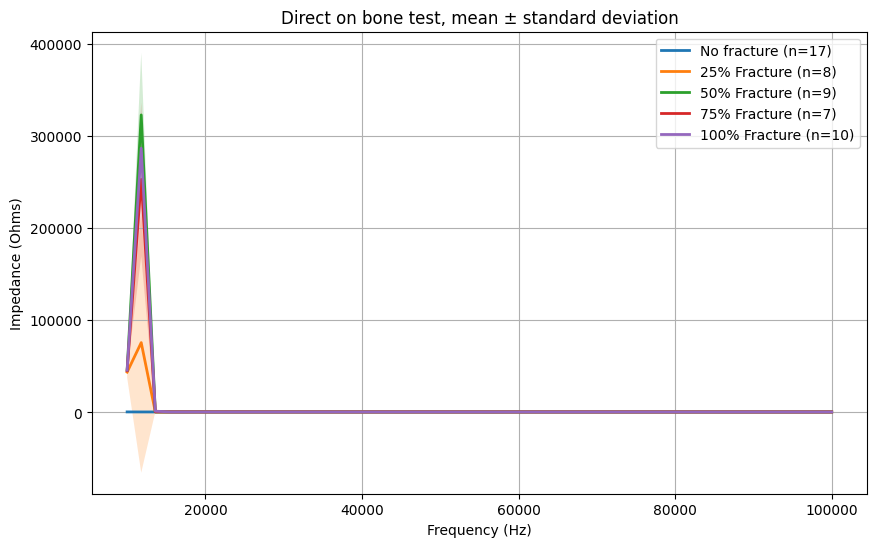

In [23]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=f"{group_name} (n={data['n']})"
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Magnitude)")
plt.title("Direct on bone test, mean ± standard deviation")
plt.legend()
plt.grid()

plt.savefig("../figures/tissue_measurements_plot_standard_deviation.png", dpi=300)
plt.show()

#### Zoomed in mean and stadard deviation plot

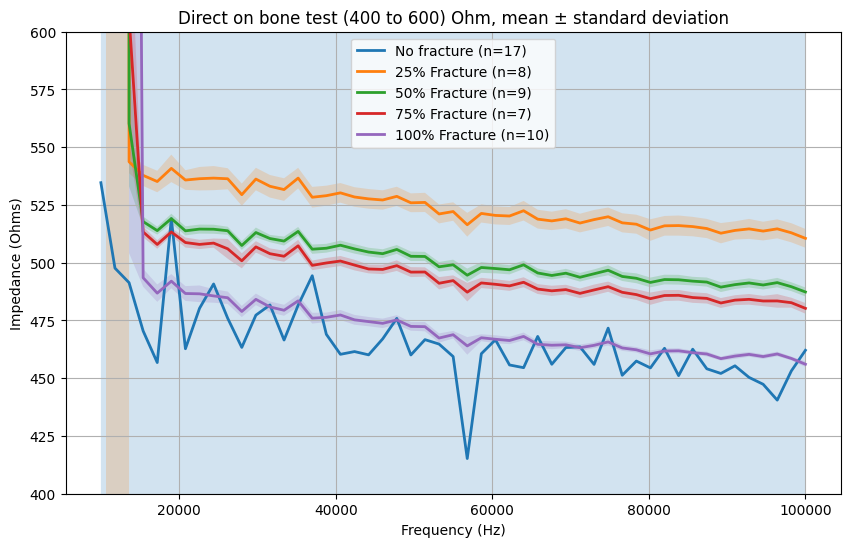

In [24]:
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=f"{group_name} (n={data['n']})"
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Magnitude)")
plt.title("Direct on bone test (400 to 600) Ohm, mean ± standard deviation")
plt.legend()
plt.grid()

plt.ylim(400, 600)

plt.savefig("../figures/tissue_measurements_plot_standard_deviation_zoomed.png", dpi=300)
plt.show()

### Print the mean and standard deviation at 1000 Hz for each group

In [25]:
for group_name, data in group_data.items():

    mean_value = np.mean(data["mean"])
    std_value = np.std(data["mean"])

    print(f"{group_name}")
    print(f"Mean: {mean_value:.2f} Ω")
    print(f"Std : {std_value:.2f} Ω")
    print()

No fracture
Mean: 466.19 Ω
Std : 18.54 Ω

25% Fracture
Mean: 2845.22 Ω
Std : 11918.08 Ω

50% Fracture
Mean: 7709.42 Ω
Std : 44996.56 Ω

75% Fracture
Mean: 6321.08 Ω
Std : 35403.27 Ω

100% Fracture
Mean: 6988.84 Ω
Std : 40041.18 Ω



### Correlation Matrix

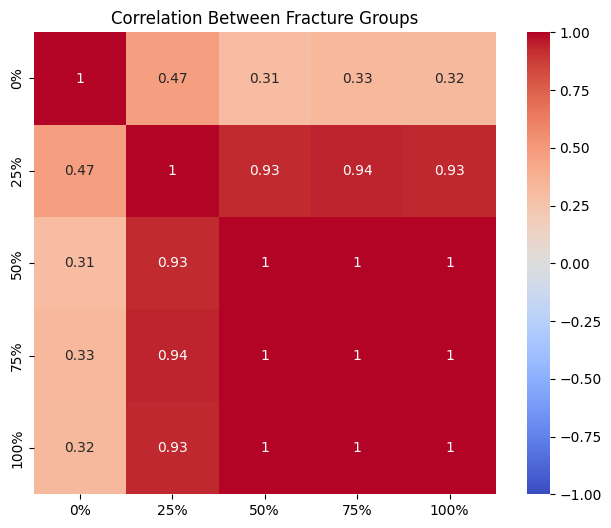

In [26]:
corr_df = pd.DataFrame()

for group_name, data in group_data.items():
    corr_df[group_name] = data["mean"]

corr_df = pd.DataFrame({
    "0%": group_data["No fracture"]["mean"],
    "25%": group_data["25% Fracture"]["mean"],
    "50%": group_data["50% Fracture"]["mean"],
    "75%": group_data["75% Fracture"]["mean"],
    "100%": group_data["100% Fracture"]["mean"]
})

corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Between Fracture Groups")

plt.savefig(
    "../figures/not_in_paper/02_tissue_measurements_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Difference Relative To Healthy


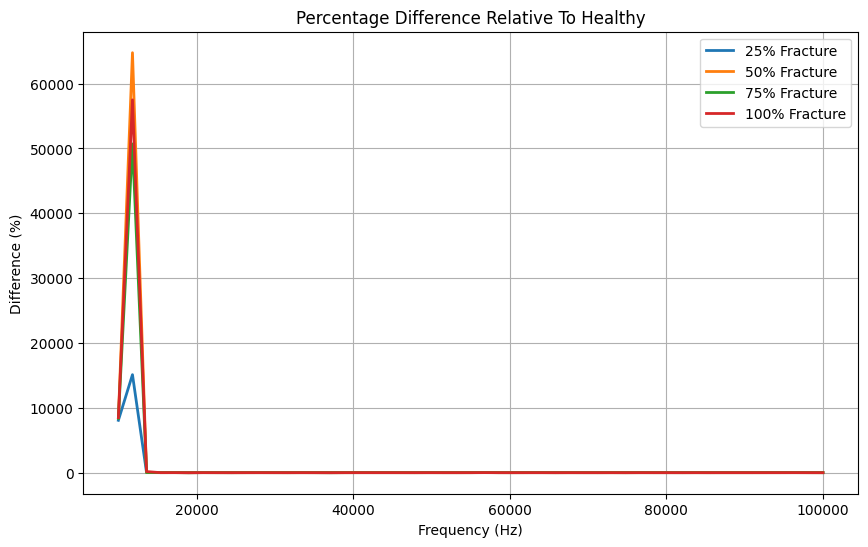

In [27]:
healthy = group_data["No fracture"]["mean"]

plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():

    if group_name == "No fracture":
        continue

    difference = (
                         data["mean"] - healthy
                 ) / healthy * 100

    plt.plot(
        data["frequency"],
        difference,
        linewidth=2,
        label=group_name
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Difference (%)")
plt.title("Percentage Difference Relative To Healthy")
plt.legend()
plt.grid()

plt.savefig(
    "../figures/not_in_paper/02_tissue_measurements_percentage_difference.png",
    dpi=300
)

plt.show()

### Best detection frequency


In [28]:
healthy = group_data["No fracture"]["mean"]

print("BEST DETECTION FREQUENCIES")
print("=" * 40)

for group_name, data in group_data.items():

    if group_name == "No fracture":
        continue

    diff = np.abs(
        (data["mean"] - healthy)
        / healthy
    )

    idx = np.argmax(diff)

    print(
        f"{group_name}: "
        f"{data['frequency'][idx]:.0f} Hz "
        f"({diff[idx] * 100:.2f}%)"
    )

BEST DETECTION FREQUENCIES
25% Fracture: 11800 Hz (15114.99%)
50% Fracture: 11800 Hz (64758.52%)
75% Fracture: 11800 Hz (50695.33%)
100% Fracture: 11800 Hz (57490.75%)


### PCA


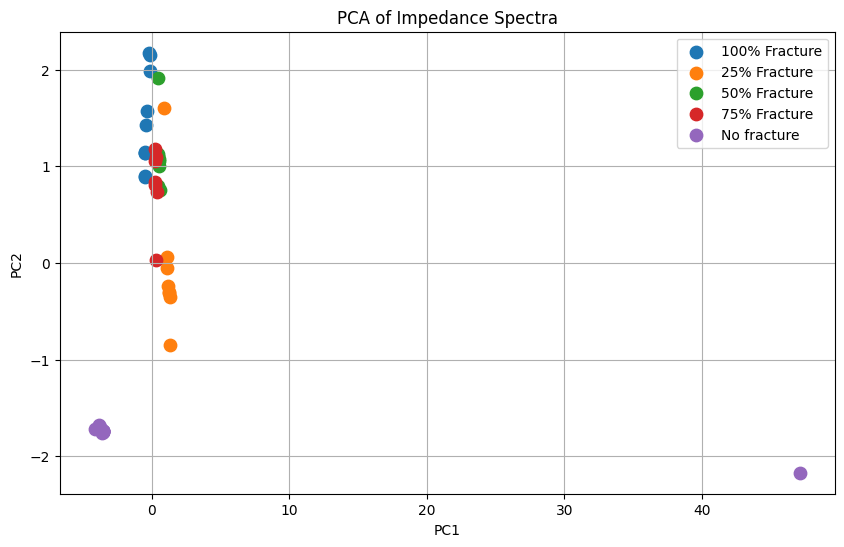

In [29]:
X = []
y = []

for group_name, data in group_data.items():

    for sweep in data["raw"]:
        X.append(sweep)
        y.append(group_name)

X = np.array(X)

# Standardize the data
X = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))

# Create distinct colors for each group
groups = np.unique(y)
colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))

for group_name in np.unique(y):
    mask = np.array(y) == group_name

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=80,
        label=group_name
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Impedance Spectra")
plt.legend()
plt.grid()

plt.savefig(
    "../figures/not_in_paper/02_tissue_measurements_PCA.png",
    dpi=300
)

plt.show()

### Phase angle

No fracture: Mean phase angle at 100 kHz = -24.60° ± 0.24°
25% Fracture: Mean phase angle at 100 kHz = -22.79° ± 0.05°
50% Fracture: Mean phase angle at 100 kHz = -22.82° ± 0.05°
75% Fracture: Mean phase angle at 100 kHz = -22.82° ± 0.05°
100% Fracture: Mean phase angle at 100 kHz = -22.76° ± 0.23°


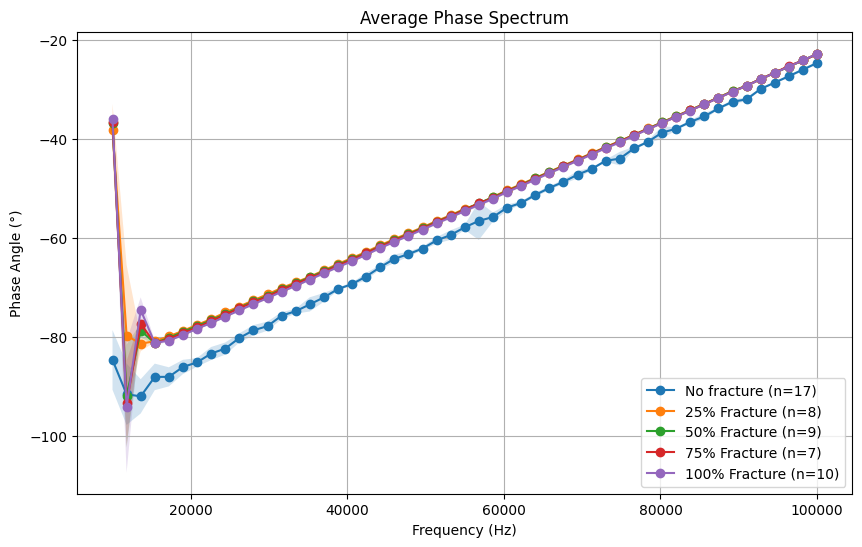

In [32]:
plt.figure(figsize=(10, 6))

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    phases = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        phase = np.degrees(
            np.arctan2(
                df["imaginary"].values,
                df["real"].values
            )
        )

        phases.append(phase)

    phases = np.vstack(phases)

    mean_phase = np.mean(phases, axis=0)
    std_phase = np.std(phases, axis=0)

    plt.plot(
        frequency,
        mean_phase,
        marker='o',
        label=f"{label} (n={len(phases)})"
    )

    plt.fill_between(
        frequency,
        mean_phase - std_phase,
        mean_phase + std_phase,
        alpha=0.2
    )

    print(f"{label}: Mean phase angle at 100 kHz = {mean_phase[-1]:.2f}° ± {std_phase[-1]:.2f}°")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (°)")
plt.title("Average Phase Spectrum")
plt.grid(True)
plt.legend()

plt.savefig(
    "../figures/not_in_paper/02_tissue_measurements_phase_angle_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()